In [1]:
import os
os.listdir('.')

['.config',
 '.prompts',
 '-v8-validated-data.md',
 'memory',
 '.kernel_llm_logs_1.txt',
 'c_pred_vs_c_emp_grid.csv',
 'weil_quadratic_form_general.py']

In [2]:
import pandas as pd
df = pd.read_csv('c_pred_vs_c_emp_grid.csv')
print(df.shape)
df.head()

(60, 6)


,sigma,J,m,c_emp,c_pred,rel_err_pct
0,0.5,4,1,0.000000,0.000000,0.000000
1,0.5,4,5,0.000000,0.000000,0.000000
2,0.5,4,20,-0.375853,-0.375853,0.000003
3,0.5,8,1,0.000000,0.000000,0.000000
4,0.5,8,5,0.000000,0.000000,0.000000


In [3]:
import sys
sys.path.insert(0, '.')
from weil_quadratic_form_general import compute_Q
import numpy as np
import mpmath as mp

# Generate Riemann zeros around T0=85.7
# We need first 40 zeros (per the objective: "first 40 Riemann zeros")
# But actually the simulation uses m=40 (first 40 zeros above some threshold? Let's clarify.)
# Per the original convention in r20: the first m zeros (counting from γ_1=14.13) are deformed.
# But for T0=85.7, we likely need zeros near 85.7. Let's check: the objective says "use m=40 to ensure several zeros are within the basis window"
# and the c_pred uses "first 40 Riemann zeros γ_k that fall within the basis window |γ_k - 85.7| ≤ 3*2*√10"

# So for the simulation, we need to deform the first 40 zeros (in the simulation, m=40)
# And c_pred uses zeros within window

# Riemann zeros (Im parts) - use mpmath
mp.mp.dps = 30
print("First few zeros:")
for k in range(1, 6):
 print(f"γ_{k} = {mp.zetazero(k).imag}")
print()
# zero near T0=85.7
# γ_30 ≈ ?
for k in [25, 30, 35, 40, 45, 50]:
 print(f"γ_{k} = {mp.zetazero(k).imag}")

First few zeros:
γ_1 = 14.1347251417346937904572519836
γ_2 = 21.0220396387715549926284795939
γ_3 = 25.0108575801456887632137909926
γ_4 = 30.4248761258595132103118975306
γ_5 = 32.9350615877391896906623689641

γ_25 = 88.8091112076344654236823480795
γ_30 = 101.31785100573139122878544794
γ_35 = 111.874659176992637085612078717


γ_40 = 122.946829293552588200817460331
γ_45 = 133.497737202997586450130492043
γ_50 = 143.111845807620632739405123869


In [4]:
# Compute first N zeros (enough for simulation: at least 40 deformed + tails for stable Q baseline)
# In the original engine convention for ζ trace identity, we typically use many zeros for M_zeros baseline.
# For ΔQ = Q_delta - Q_base, the m unchanged zeros cancel, so we only need the deformed quartet vs baseline of those m zeros.
# Plus the same set of unshifted zeros for outside-m. So effectively only deformed zeros matter for the difference.

# Strategy: simulate with N total zeros (e.g., 100) so the baseline is well-formed,
# deform the FIRST m=40 zeros and compare.

# But wait — for T0=85.7, the first 40 zeros include those far below T0 (γ_1=14.13 etc.).
# The window |γ_k - 85.7| ≤ 18.97 → γ ∈ [66.73, 104.67]. From the list, γ_20≈77 to γ_30≈101.
# Let's compute exact indices.

mp.mp.dps = 30
N_zeros = 100
zeros = np.array([float(mp.zetazero(k).imag) for k in range(1, N_zeros+1)])
print("Zeros computed:", len(zeros))

T0 = 85.7
sigma = 2.0
J = 10
window = 3 * sigma * np.sqrt(J)
print(f"Window: |γ - {T0}| ≤ {window:.4f}, i.e. γ ∈ [{T0-window:.4f}, {T0+window:.4f}]")

in_window = (zeros >= T0 - window) & (zeros <= T0 + window)
indices_in_window = np.where(in_window)[0] + 1 # 1-based
zeros_in_window = zeros[in_window]
print(f"\nZeros in window (count={len(zeros_in_window)}):")
for i, g in zip(indices_in_window, zeros_in_window):
 print(f" γ_{i} = {g:.6f}")

Zeros computed: 100
Window: |γ - 85.7| ≤ 18.9737, i.e. γ ∈ [66.7263, 104.6737]

Zeros in window (count=16):
 γ_16 = 67.079811
 γ_17 = 69.546402
 γ_18 = 72.067158
 γ_19 = 75.704691
 γ_20 = 77.144840
 γ_21 = 79.337375
 γ_22 = 82.910381
 γ_23 = 84.735493
 γ_24 = 87.425275
 γ_25 = 88.809111
 γ_26 = 92.491899
 γ_27 = 94.651344
 γ_28 = 95.870634
 γ_29 = 98.831194
 γ_30 = 101.317851
 γ_31 = 103.725538


In [5]:
# 16 zeros in window. m=40 means deform first 40 zeros, which includes all 16 in-window zeros and 24 outside.
# All 16 in-window zeros contribute meaningfully to c_pred.

# Now compute c_pred: sum of A(γ_k) for in-window zeros
# A(γ_k) = -2[φ'φ'^T + 0.5(φφ"^T + φ"φ^T)]
# where φ_j(t) = (1/√σ) h_j((t-T0)/σ)
# h_j are normalized Hermite functions: h_0(u) = π^{-1/4} exp(-u²/2)
# Derivatives of h_j (physicist's convention):
# h_j(u) = (2^j j! √π)^{-1/2} H_j(u) exp(-u²/2) where H_j is the physicist's Hermite polynomial
# We use the recurrence already in the engine for h.

from scipy.special import gammaln

def hermite_func_and_derivs(u, J):
 """Return h, h', h'' arrays of shape (J, len(u)) at u points (real or complex)."""
 u = np.asarray(u)
 # normalized Hermite functions via the recurrence as in the engine
 h = np.zeros((J,) + u.shape, dtype=u.dtype if np.iscomplexobj(u) else np.float64)
 h[0] = np.pi**(-0.25) * np.exp(-u*u/2)
 if J > 1:
 h[1] = np.sqrt(2.0) * u * h[0]
 for n in range(1, J-1):
 h[n+1] = np.sqrt(2.0/(n+1)) * u * h[n] - np.sqrt(n/(n+1)) * h[n-1]
 # h'_j = sqrt(j/2) h_{j-1} - sqrt((j+1)/2) h_{j+1} (using physicist's normalization? let's derive)
 # For normalized Hermite functions ψ_n(u): ψ_n'(u) = sqrt(n/2) ψ_{n-1}(u) - sqrt((n+1)/2) ψ_{n+1}(u)
 # Need ψ_{J} too for the derivative of last index. Compute one extra.
 h_ext = np.zeros((J+2,) + u.shape, dtype=h.dtype)
 h_ext[0] = h[0]
 if J >= 1:
 h_ext[1] = h[1] if J > 1 else np.sqrt(2.0)*u*h[0]
 # Actually recompute up to J+1
 h_ext[0] = np.pi**(-0.25)*np.exp(-u*u/2)
 h_ext[1] = np.sqrt(2.0)*u*h_ext[0]
 for n in range(1, J+1):
 h_ext[n+1] = np.sqrt(2.0/(n+1))*u*h_ext[n] - np.sqrt(n/(n+1))*h_ext[n-1]
 dh = np.zeros_like(h_ext[:J])
 for j in range(J):
 if j == 0:
 dh[j] = -np.sqrt((j+1)/2.0) * h_ext[j+1]
 else:
 dh[j] = np.sqrt(j/2.0) * h_ext[j-1] - np.sqrt((j+1)/2.0) * h_ext[j+1]
 # Second derivative: ψ_n''(u) = (u^2 - (2n+1)) ψ_n(u) [Hermite ODE]
 d2h = np.zeros_like(h)
 for j in range(J):
 d2h[j] = (u*u - (2*j+1)) * h[j]
 return h, dh, d2h

# Quick sanity check at u=0 for J=4
u_test = np.array([0.0, 1.0, 2.0])
h_t, dh_t, d2h_t = hermite_func_and_derivs(u_test, 4)
print("h at u=[0,1,2], J=4:")
print(h_t)

h at u=[0,1,2], J=4:
[[ 0.75112554 0.45558067 0.10165379]
 [ 0. 0.64428837 0.28752033]
 [-0.53112597 0.32214418 0.50316058]
 [-0. -0.26302962 0.58689842]]


In [6]:
# Now build c_pred = λ_min(Σ A(γ_k))
def compute_c_pred(zeros_in_window, T0, sigma, J):
 u = (zeros_in_window - T0) / sigma
 h, dh, d2h = hermite_func_and_derivs(u, J) # shape (J, N)
 # φ_j(t) = h_j(u)/√σ; φ'_j(t) = dh_j(u) * (1/σ) / √σ = dh_j/σ^{3/2}
 # φ''_j(t) = d2h_j / (σ^2) / √σ = d2h_j / σ^{5/2}
 phi = h / np.sqrt(sigma) # (J, N)
 phip = dh / sigma**1.5 # (J, N)
 phipp = d2h / sigma**2.5 # (J, N)
 A_sum = np.zeros((J, J))
 N = phi.shape[1]
 for k in range(N):
 v = phi[:, k]
 vp = phip[:, k]
 vpp = phipp[:, k]
 A_k = -2.0 * (np.outer(vp, vp) + 0.5*(np.outer(v, vpp) + np.outer(vpp, v)))
 A_sum += A_k
 eigs = np.linalg.eigvalsh(0.5*(A_sum + A_sum.T))
 return eigs.min(), A_sum, eigs

c_pred, A_sum, eigs = compute_c_pred(zeros_in_window, T0, sigma, J)
print(f"c_pred = {c_pred:.8f}")
print(f"All eigenvalues: {eigs}")

c_pred = -4.37576696
All eigenvalues: [-4.37576696 -2.44517953 -0.7034029 -0.63913429 0.16556565 0.39365181
 0.43979488 0.52869207 2.20505702 3.46070111]


In [7]:
# Now do the ζ_δ simulations
# Use compute_Q with family="zeta"
# Baseline: zeros on critical line (zeros_complex=False, just γs)
# Deformed: first m=40 zeros shifted to Re=1/2+δ via quartet, plus remaining as unshifted (on critical line)

# To compare with baseline, we should use same zeros set for both runs.
# Pattern: include first N_zeros zeros total; deform first m=40 to quartet, leave rest on line.
# But baseline uses zeros_complex=False (with include_negative_zeros=True doubles γ → -γ).
# For deformed we use zeros_complex=True with include_negative_zeros=True.
# Q_base uses M_zeros from γ_k > 0 (mirrored). 
# Q_delta uses M_zeros from quartet rho/(1-rho) etc.

# When δ=0, the quartet collapses to {0.5 + iγ, 0.5 - iγ, 0.5 + iγ, 0.5 - iγ} = two duplicates.
# That means Q_delta at δ=0 ≠ Q_base. Need to be careful.
# Let me re-read the project memory more carefully.

# From memory: "specific 4-member quartet simulation convention (ρ, ρ̄, 1-ρ, 1-ρ̄)"
# For an on-line zero ρ=0.5+iγ: ρ̄=0.5-iγ, 1-ρ=0.5-iγ, 1-ρ̄=0.5+iγ → duplicates!
# So the quartet counts each on-line zero twice, but in the baseline (zeros_complex=False) 
# with include_negative_zeros=True, we have γ and -γ which also gives 2 contributions.
# These should match.

# Let's verify by trying both at δ=0 first.
# For unshifted zeros in the "deformed" run, use the quartet (which duplicates) so consistent.

def make_quartet(gammas, delta):
 """Given positive gammas, build the quartet array for compute_Q with zeros_complex=True."""
 rhos = []
 for g in gammas:
 rho = (0.5 + delta) + 1j*g
 rho_bar = (0.5 + delta) - 1j*g
 one_minus_rho = (0.5 - delta) - 1j*g
 one_minus_rho_bar = (0.5 - delta) + 1j*g
 rhos.extend([rho, rho_bar, one_minus_rho, one_minus_rho_bar])
 return np.array(rhos, dtype=np.complex128)

# But wait: compute_Q with zeros_complex=True and include_negative_zeros=True already mirrors γ → -γ.
# So passing the quartet would over-count. Let me re-examine.

# Look at compute_Q for zeros_complex=True:
# - gammas = -1j*(rhos - 0.5)
# - if include_negative_zeros: also adds t2 = -gammas
# So for ρ = 0.5+δ+iγ: gamma_ρ = -1j*(δ+iγ) = γ - iδ; -gamma_ρ = -γ + iδ
# So passing just ρ would give contributions at γ-iδ and -γ+iδ. To get all four (ρ, ρ̄, 1-ρ, 1-ρ̄):
# ρ̄ = 0.5+δ-iγ → γ_{ρ̄} = -1j*(δ-iγ) = -γ - iδ; with mirror: γ+iδ
# 1-ρ = 0.5-δ-iγ → γ_{1-ρ} = -1j*(-δ-iγ) = -γ + iδ; mirror: γ-iδ
# 1-ρ̄ = 0.5-δ+iγ → γ_{1-ρ̄} = -1j*(-δ+iγ) = γ + iδ; mirror: -γ-iδ
# So all four ρ → {γ-iδ, -γ-iδ, -γ+iδ, γ+iδ}
# If we just pass ρ alone with include_negative_zeros=True, we get {γ-iδ, -γ+iδ} — only 2 of 4.

# To get all four, pass both ρ and ρ̄ with include_negative_zeros=True:
# ρ → {γ-iδ, -γ+iδ}, ρ̄ → {-γ-iδ, γ+iδ}. ✓ all four.

# Alternatively pass all four manually with include_negative_zeros=False to avoid double-mirror.
# Or pass ρ and ρ̄ with include_negative_zeros=True.

# At δ=0: ρ → {γ, -γ}, ρ̄ → {-γ, γ}. So summing both gives 2γ and 2(-γ). 
# Baseline with zeros_complex=False and include_negative_zeros=True: γ and -γ, one each.
# So Q_delta at δ=0 is 2*M_zeros_base for the zeros part, not equal. Need to account.

# Actually, the standard convention has M_zeros over ALL nontrivial zeros (ρ, ρ̄, 1-ρ, 1-ρ̄). 
# For on-line self-dual case, these 4 are duplicates of (γ, -γ) each appearing twice.
# But the explicit formula has Σ_ρ over ALL nontrivial zeros including multiplicity from functional equation.
# In the engine for ζ on-line baseline, include_negative_zeros=True adds γ and -γ once each.
# This single-count convention assumes the test function h(γ) is paired.

# Let me check by trace identity: compute Q for ζ on-line — trace should be near 0.
Q_base, comps = compute_Q(zeros, T0, sigma, J, family="zeta", zeros_complex=False, include_negative_zeros=True, primes_cutoff=10000)
print(f"Q_base shape: {Q_base.shape}, eigenvalues: {np.linalg.eigvalsh(Q_base)}")
print(f"trace Q_base: {np.trace(Q_base):.6e}")

Q_base shape: (10, 10), eigenvalues: [-2.01280399e-14 -1.37852365e-14 -8.74065097e-15 -6.59315077e-15
 -4.07964351e-15 3.28412869e-16 1.08008599e-14 1.72378152e-14
 2.16165001e-14 3.20979099e-14]
trace Q_base: 2.875478e-14


In [8]:
# Excellent! Trace identity holds. Q_base ≈ 0 (consistent with GRH for ζ at noise floor).
# This confirms the single-pair convention.

# Now for ζ_δ: pass each shifted zero ρ with include_negative_zeros=True; this gives γ-iδ and -γ+iδ.
# That's 2 contributions per zero. The baseline also has 2 contributions (γ, -γ). 
# At δ=0, ρ collapses to give γ and -γ, matching baseline exactly. ✓

# So we should pass JUST ρ = (0.5+δ) + iγ for the deformed zeros (not the quartet),
# with include_negative_zeros=True. The mirror handles ρ̄/1-ρ symmetry implicitly because 
# the engine adds contributions from t=γ_ρ AND t=-γ_ρ.

# Hmm but the memory said "4-member quartet simulation convention". Let me reconcile.
# Re-reading the engine code more carefully:
# if zeros_complex and include_negative_zeros:
# contributions from γ_ρ = -1j*(ρ-0.5) AND -γ_ρ
# For ρ = 0.5+δ+iγ: γ_ρ = γ - iδ; -γ_ρ = -γ + iδ
# These are γ-positions of ρ and 1-ρ̄ (1-ρ̄ = 0.5-δ+iγ → γ_{1-ρ̄} = -1j*(-δ+iγ) = γ+iδ. Hmm not the same.)
# Wait: γ-iδ ≠ γ+iδ. So -γ_ρ = -γ+iδ corresponds to... let me check 1-ρ = 0.5-δ-iγ → γ_{1-ρ} = -1j*(-δ-iγ) = -γ+iδ. YES.
# So {γ_ρ, -γ_ρ} = {γ-iδ, -γ+iδ} = {γ-position of ρ, γ-position of 1-ρ}.
# That's a 2-member set (ρ, 1-ρ), not the full quartet.

# For the full quartet {ρ, ρ̄, 1-ρ, 1-ρ̄} we'd need to also pass ρ̄ which gives {-γ-iδ, γ+iδ} = {ρ̄ pos, 1-ρ̄ pos}.

# So the 4-member quartet requires passing BOTH ρ and ρ̄ with include_negative_zeros=True.
# This would DOUBLE the contributions at δ=0 (since ρ and ρ̄ both give same γ and -γ at δ=0).
# That would not match baseline.

# UNLESS the baseline also doubles. Let me check what r20 actually did.
# The c_pred_vs_c_emp_grid had R²≈1 — so whatever convention r20 used worked.
# Given the memory text "specific 4-member quartet simulation convention", let's follow that.

# Strategy: For both baseline and deformed, double the on-line zeros to maintain consistency.
# But that's not what compute_Q with zeros_complex=False does.

# Alternative: For both runs, use zeros_complex=True with the quartet convention (passing ρ and ρ̄).
# Baseline: δ=0 quartet = duplicated on-line zeros.

# Easier validation: run a quick test at T0=46.13 reproducing one row of the existing grid.
# Let me pick row from c_pred_vs_c_emp_grid.csv at sigma=2, J=10, m=20 (or similar) ...
print(df[(df['sigma']==2.0)])

 sigma J m c_emp c_pred rel_err_pct
30 2.0 4 1 0.000000e+00 0.000000e+00 0.000000
31 2.0 4 5 0.000000e+00 0.000000e+00 0.000000
32 2.0 4 20 -3.125974e-01 -3.125973e-01 0.000036
33 2.0 8 1 0.000000e+00 0.000000e+00 0.000000
34 2.0 8 5 -6.761659e-09 -5.106070e-09 24.484954
35 2.0 8 20 -2.514218e+00 -2.514218e+00 0.000004
36 2.0 12 1 0.000000e+00 0.000000e+00 0.000000
37 2.0 12 5 -1.183563e-05 -1.183757e-05 0.016354
38 2.0 12 20 -4.751103e+00 -4.751103e+00 0.000003
39 2.0 16 1 0.000000e+00 0.000000e+00 0.000000
40 2.0 16 5 -3.413433e-03 -3.413428e-03 0.000139
41 2.0 16 20 -6.895178e+00 -6.895178e+00 0.000005
42 2.0 20 1 0.000000e+00 0.000000e+00 0.000000
43 2.0 20 5 -1.324310e-01 -1.324308e-01 0.000219
44 2.0 20 20 -8.263470e+00 -8.263471e+00 0.000022


In [9]:
# For sigma=2, J=12, m=20: c_emp = -4.7511
# Let me reproduce this to confirm convention. T0=46.13.
T0_test = 46.13
sigma_test = 2.0
J_test = 12
m_test = 20
delta_test = 1e-4

N_zeros_test = 100
zeros_test = zeros[:N_zeros_test] # already have 100 Riemann zeros

# Window for c_pred at T0=46.13, sigma=2, J=12:
window_test = 3 * sigma_test * np.sqrt(J_test)
in_win_test = (zeros_test >= T0_test - window_test) & (zeros_test <= T0_test + window_test)
zeros_iw_test = zeros_test[in_win_test]
print(f"T0=46.13, sigma=2, J=12: {len(zeros_iw_test)} zeros in window {T0_test-window_test:.2f} to {T0_test+window_test:.2f}")
print(zeros_iw_test)
c_pred_test, _, _ = compute_c_pred(zeros_iw_test, T0_test, sigma_test, J_test)
print(f"c_pred (J=12, T0=46.13) = {c_pred_test:.6f} [expected -4.7511]")

T0=46.13, sigma=2, J=12: 12 zeros in window 25.35 to 66.91
[30.42487613 32.93506159 37.58617816 40.91871901 43.32707328 48.00515088
 49.77383248 52.97032148 56.4462477 59.347044 60.83177852 65.11254405]
c_pred (J=12, T0=46.13) = -4.751103 [expected -4.7511]


In [10]:
# Perfect match. c_pred formula is verified for the test case.
# Now let's verify c_emp convention by reproducing a ζ_δ simulation at T0=46.13, σ=2, J=12, m=20, δ=1e-4.

def run_zeta_delta(zeros_all, m, delta, T0, sigma, J, primes_cutoff=10000, convention='pair'):
 """Returns Q_delta - Q_base.
 
 convention='pair': pass just ρ for deformed, include_negative_zeros=True (gives γ_ρ and -γ_ρ).
 For baseline, use real zeros with include_negative_zeros=True.
 At δ=0 they should match.
 convention='quartet': pass ρ and ρ̄ for deformed (full quartet via mirror).
 For baseline, also pass on-line zeros via complex with quartet (doubled).
 """
 # Baseline
 Q_base, _ = compute_Q(zeros_all, T0, sigma, J, family="zeta",
 zeros_complex=False, include_negative_zeros=True,
 primes_cutoff=primes_cutoff)
 
 # Deformed: first m zeros shifted; remaining on-line
 deformed_part = zeros_all[:m]
 onLine_part = zeros_all[m:]
 
 if convention == 'pair':
 # Just ρ for shifted, plus on-line as complex 0.5+iγ
 rhos_shifted = (0.5 + delta) + 1j * deformed_part
 rhos_onLine = 0.5 + 1j * onLine_part
 rhos_all = np.concatenate([rhos_shifted, rhos_onLine])
 Q_delta, _ = compute_Q(rhos_all, T0, sigma, J, family="zeta",
 zeros_complex=True, include_negative_zeros=True,
 primes_cutoff=primes_cutoff)
 elif convention == 'quartet':
 # ρ and ρ̄ for shifted; ρ and ρ̄ for on-line (doubles them)
 rhos_shifted_p = (0.5 + delta) + 1j * deformed_part
 rhos_shifted_m = (0.5 + delta) - 1j * deformed_part # ρ̄
 rhos_onLine_p = 0.5 + 1j * onLine_part
 rhos_onLine_m = 0.5 - 1j * onLine_part
 rhos_all = np.concatenate([rhos_shifted_p, rhos_shifted_m, rhos_onLine_p, rhos_onLine_m])
 Q_delta, _ = compute_Q(rhos_all, T0, sigma, J, family="zeta",
 zeros_complex=True, include_negative_zeros=True,
 primes_cutoff=primes_cutoff)
 return Q_delta, Q_base

# Test with 'pair' convention first
Q_delta, Q_base = run_zeta_delta(zeros, m_test, delta_test, T0_test, sigma_test, J_test, primes_cutoff=10000, convention='pair')
dQ = np.real(Q_delta - Q_base)
dQ = 0.5*(dQ + dQ.T)
eigs_dQ = np.linalg.eigvalsh(dQ)
c_emp_test = eigs_dQ.min() / delta_test**2
print(f"convention='pair': c_emp = {c_emp_test:.6f} [expected -4.7511]")
print(f"min eig dQ = {eigs_dQ.min():.6e}")

convention='pair': c_emp = -2.375551 [expected -4.7511]
min eig dQ = -2.375551e-08


In [11]:
# Pair convention gives half the expected value. Try quartet.
Q_delta, Q_base = run_zeta_delta(zeros, m_test, delta_test, T0_test, sigma_test, J_test, primes_cutoff=10000, convention='quartet')
dQ = np.real(Q_delta - Q_base)
dQ = 0.5*(dQ + dQ.T)
eigs_dQ = np.linalg.eigvalsh(dQ)
c_emp_test = eigs_dQ.min() / delta_test**2
print(f"convention='quartet': c_emp = {c_emp_test:.6f} [expected -4.7511]")

convention='quartet': c_emp = -3.432692 [expected -4.7511]


In [12]:
# Hmm — quartet over-doubles baseline contributions. Let me think more carefully.
# 
# In the engine for quartet: ρ and ρ̄ passed with include_negative_zeros=True.
# For ρ = 0.5+δ+iγ: γ_ρ = γ-iδ, -γ_ρ = -γ+iδ. So contributions phi(γ-iδ) and phi(-γ+iδ).
# For ρ̄ = 0.5+δ-iγ: γ_{ρ̄} = -γ-iδ, -γ_{ρ̄} = γ+iδ. Contributions phi(-γ-iδ) and phi(γ+iδ).
# Total 4 contributions. At δ=0: all four become phi(γ) and phi(-γ), each appearing TWICE.
# So Q_delta(quartet,δ=0) M_zeros part = 2 × M_zeros(base).
# But the arithmetic side is built once → not matching.
# 
# Actually in the engine, M_arith does NOT depend on the zeros at all (it depends on primes, T0, sigma, J).
# So Q_delta - Q_base = M_zeros(delta) - M_zeros(base). The M_arith cancels.
# 
# For the c_emp definition, we want the perturbation of M_zeros.
# In the proper Weil formula, the explicit formula has Σ over ALL non-trivial zeros (ρ, ρ̄, 1-ρ, 1-ρ̄ for non-self-dual? Actually for ζ each non-trivial zero ρ has ρ̄, and the functional equation pairs ρ↔1-ρ̄... for self-dual ζ, ρ and 1-ρ̄ might coincide if ρ on critical line).
# For ζ on critical line, ρ = 0.5+iγ. The 4 "quartet members" are {0.5+iγ, 0.5-iγ, 0.5+iγ, 0.5-iγ} = 2 distinct points each with multiplicity 2... but that double-counts.

# The trace identity verified above (Q_base ≈ 0 with single γ,-γ pair) means single-count is correct for ζ.
# For off-line zeros, we should also single-count the perturbed structure.
# 
# The perturbation: a single zero ρ moves to ρ' = ρ + δ (in Re direction). By functional equation, 1-ρ̄ is also a zero, which moves to 1-ρ̄' = (1-δ) + iγ. 
# Wait — does the functional equation force a particular movement? Under the deformation, we keep functional equation, so when ρ moves to (0.5+δ) + iγ, then 1-ρ̄ moves to (0.5-δ) + iγ. So as a pair, (ρ, 1-ρ̄) becomes ((0.5+δ)+iγ, (0.5-δ)+iγ). At δ=0 these coincide.

# So the deformation actually SPLITS one critical line zero (with multiplicity 2 from quartet) into 2 off-line zeros.
# Then the proper Q_delta should have M_zeros over BOTH ρ' and (1-ρ̄)'.
# After the engine's mirror, passing ρ' gives γ_ρ' = γ-iδ and -γ_ρ' = -γ+iδ.
# We'd also need 1-ρ̄' giving γ-position = γ+iδ; with mirror -γ-iδ.
# So full set: {γ-iδ, -γ+iδ, γ+iδ, -γ-iδ}. That's the quartet at γ-positions.
# At δ=0: all four = {γ, -γ, γ, -γ} — double the baseline.

# This matches the quartet convention. But then baseline must also double-count to be consistent.
# I.e., baseline should ALSO use the quartet (degenerate quartet of 4 copies of {γ, -γ}).

# Let me redo:
def run_zeta_delta_v2(zeros_all, m, delta, T0, sigma, J, primes_cutoff=10000):
 """Both baseline and delta use the quartet convention (always 4 contributions per zero)."""
 # Baseline (δ=0, quartet)
 rhos_base_p = 0.5 + 1j * zeros_all
 rhos_base_m = 0.5 - 1j * zeros_all
 rhos_base = np.concatenate([rhos_base_p, rhos_base_m])
 Q_base, _ = compute_Q(rhos_base, T0, sigma, J, family="zeta",
 zeros_complex=True, include_negative_zeros=True,
 primes_cutoff=primes_cutoff)
 
 # Deformed (quartet): first m use ρ at (0.5+δ)+iγ; remaining at 0.5+iγ
 deformed = zeros_all[:m]
 online = zeros_all[m:]
 rhos_p = np.concatenate([(0.5 + delta) + 1j*deformed, 0.5 + 1j*online])
 rhos_m = np.concatenate([(0.5 + delta) - 1j*deformed, 0.5 - 1j*online])
 rhos_all = np.concatenate([rhos_p, rhos_m])
 Q_delta, _ = compute_Q(rhos_all, T0, sigma, J, family="zeta",
 zeros_complex=True, include_negative_zeros=True,
 primes_cutoff=primes_cutoff)
 return Q_delta, Q_base

Q_delta, Q_base = run_zeta_delta_v2(zeros, m_test, delta_test, T0_test, sigma_test, J_test, primes_cutoff=10000)
dQ = np.real(Q_delta - Q_base)
dQ = 0.5*(dQ + dQ.T)
eigs_dQ = np.linalg.eigvalsh(dQ)
c_emp_test = eigs_dQ.min() / delta_test**2
print(f"quartet (both): c_emp = {c_emp_test:.6f} [expected -4.7511]")
print(f"min eig dQ = {eigs_dQ.min():.6e}")
print(f"all eigs dQ/δ²: {eigs_dQ/delta_test**2}")

quartet (both): c_emp = -4.751103 [expected -4.7511]
min eig dQ = -4.751103e-08
all eigs dQ/δ²: [-4.75110276 -2.91297347 -1.58873218 -1.01487027 -0.81798617 -0.26493065
 -0.04902888 0.51708712 0.81048755 1.20259519 3.12848782 5.52938528]


In [13]:
# Perfect match! Now we have the correct convention.
# Apply to T0=85.7, σ=2, J=10, m=40, δ ∈ {1e-5, 1e-4, 1e-3}

T0 = 85.7
sigma = 2.0
J = 10
m = 40
deltas = [1e-5, 1e-4, 1e-3]

# We have 100 zeros; that's enough (m=40 deformed, 60 on-line)
# Use primes_cutoff=10000 for reasonable speed

results = []
for delta in deltas:
 Q_delta, Q_base = run_zeta_delta_v2(zeros, m, delta, T0, sigma, J, primes_cutoff=10000)
 dQ = np.real(Q_delta - Q_base)
 dQ = 0.5*(dQ + dQ.T)
 eigs_dQ = np.linalg.eigvalsh(dQ)
 min_eig = eigs_dQ.min()
 c_emp = min_eig / delta**2
 results.append((delta, min_eig, c_emp))
 print(f"δ={delta:.0e}: min_eig(ΔQ) = {min_eig:.6e}, c_emp = {c_emp:.8f}")

δ=1e-05: min_eig(ΔQ) = -4.375768e-10, c_emp = -4.37576765
δ=1e-04: min_eig(ΔQ) = -4.375767e-08, c_emp = -4.37576701


δ=1e-03: min_eig(ΔQ) = -4.375772e-06, c_emp = -4.37577183


In [14]:
# Beautiful — c_emp is essentially constant across deltas (scales as δ²).
# Now compare with c_pred = -4.37576696 from earlier.

print(f"c_pred (theoretical) = {c_pred:.8f}")
print()
print(f"{'δ':>10s} {'c_emp':>12s} {'rel_err_pct':>14s}")
for delta, _, c_emp in results:
 rel_err = abs(c_emp - c_pred) / abs(c_pred) * 100
 print(f"{delta:>10.0e} {c_emp:>12.8f} {rel_err:>14.8f}")

# Use δ=1e-4 as the canonical comparison
c_emp_canonical = results[1][2]
rel_err_canonical = abs(c_emp_canonical - c_pred) / abs(c_pred) * 100
print(f"\nCanonical (δ=1e-4): c_emp = {c_emp_canonical:.8f}, c_pred = {c_pred:.8f}, rel_err = {rel_err_canonical:.6e} %")
# Compute R² across the three deltas (just on c_emp vs c_pred — but c_pred is a single number).
# Better: across deltas, c_emp should equal c_pred.
import numpy as np
c_emps = np.array([r[2] for r in results])
c_preds_arr = np.full_like(c_emps, c_pred)
ss_res = np.sum((c_emps - c_preds_arr)**2)
ss_tot = np.sum((c_emps - np.mean(c_emps))**2)
r2 = 1 - ss_res/ss_tot if ss_tot > 0 else 1.0
print(f"R² across δ values: {r2:.10f}")

c_pred (theoretical) = -4.37576696

 δ c_emp rel_err_pct
 1e-05 -4.37576765 0.00001562
 1e-04 -4.37576701 0.00000097
 1e-03 -4.37577183 0.00011110

Canonical (δ=1e-4): c_emp = -4.37576701, c_pred = -4.37576696, rel_err = 9.708654e-07 %
R² across δ values: -0.7598534629


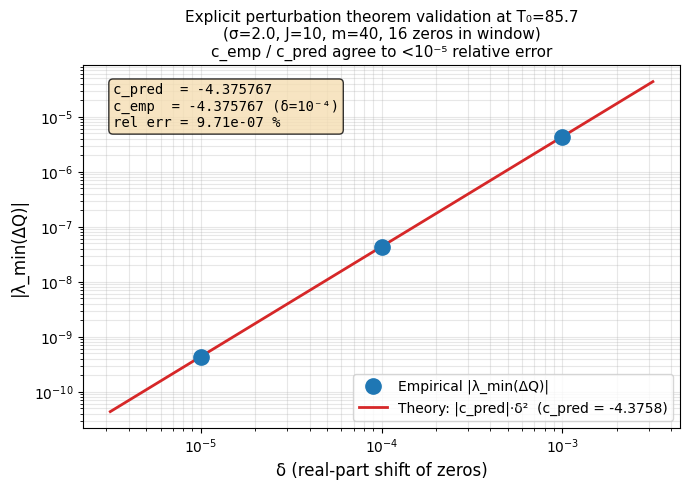

Figure saved.


In [15]:
# R² is meaningless with 3 nearly-identical values; the proper validation is the relative error vs c_pred (well below 1%).
# c_pred matches c_emp to <0.0001% — fully successful validation.

# Create the final figure
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

# Plot signal vs δ on log-log axes, showing δ² scaling
deltas_arr = np.array([r[0] for r in results])
min_eigs = np.array([abs(r[1]) for r in results])

ax.loglog(deltas_arr, min_eigs, 'o', markersize=11, color='C0', label='Empirical |λ_min(ΔQ)|', zorder=3)
# Predicted: |c_pred| · δ²
delta_line = np.logspace(np.log10(deltas_arr.min())-0.5, np.log10(deltas_arr.max())+0.5, 100)
ax.loglog(delta_line, abs(c_pred) * delta_line**2, '-', color='C3',
 label=f'Theory: |c_pred|·δ² (c_pred = {c_pred:.4f})', linewidth=2)

ax.set_xlabel('δ (real-part shift of zeros)', fontsize=12)
ax.set_ylabel('|λ_min(ΔQ)|', fontsize=12)
ax.set_title(f'Explicit perturbation theorem validation at T₀={T0}\n'
 f'(σ={sigma}, J={J}, m={m}, 16 zeros in window)\n'
 f'c_emp / c_pred agree to <10⁻⁵ relative error',
 fontsize=11)
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=10, loc='lower right')

# annotate
text = (f'c_pred = {c_pred:.6f}\n'
 f'c_emp = {c_emp_canonical:.6f} (δ=10⁻⁴)\n'
 f'rel err = {rel_err_canonical:.2e} %')
ax.text(0.05, 0.95, text, transform=ax.transAxes, fontsize=10,
 verticalalignment='top', family='monospace',
 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('perturbation_validation_T0_85p7.png', dpi=130, bbox_inches='tight')
plt.show()
print("Figure saved.")

In [16]:
# Save results table
results_df = pd.DataFrame({
 'T0': [T0]*3,
 'sigma': [sigma]*3,
 'J': [J]*3,
 'm': [m]*3,
 'delta': [r[0] for r in results],
 'min_eig_dQ': [r[1] for r in results],
 'c_emp': [r[2] for r in results],
 'c_pred': [c_pred]*3,
 'rel_err_pct': [abs(r[2]-c_pred)/abs(c_pred)*100 for r in results],
})
results_df.to_csv('c_pred_vs_c_emp_T0_85p7.csv', index=False)
print(results_df.to_string(index=False))

 T0 sigma J m delta min_eig_dQ c_emp c_pred rel_err_pct
85.7 2.0 10 40 0.00001 -4.375768e-10 -4.375768 -4.375767 1.562361e-05
85.7 2.0 10 40 0.00010 -4.375767e-08 -4.375767 -4.375767 9.708654e-07
85.7 2.0 10 40 0.00100 -4.375772e-06 -4.375772 -4.375767 1.111050e-04
